In [1]:
import numpy as np ; import matplotlib.pyplot as plt

def load_variables_to_dict(file_path):
    variables_dict = {}
    with open(file_path, 'r') as file:
        lines = file.readlines()
    for line in lines:
        if line.startswith('Variable'):
            parts = line.split(':')
            if len(parts) > 1:
                variable_info = parts[1].split('def =')
                if len(variable_info) > 1:
                    var_name = variable_info[0].split()[0].strip()
                    numerical_values = variable_info[1].split()
                    for value in numerical_values:
                        try:
                            num_value = float(value)
                            variables_dict[var_name.split(',')[0]] = num_value
                            break
                        except ValueError:
                            continue
    return variables_dict


minimum friction dissipation increment = -2.5135900000000002e-09


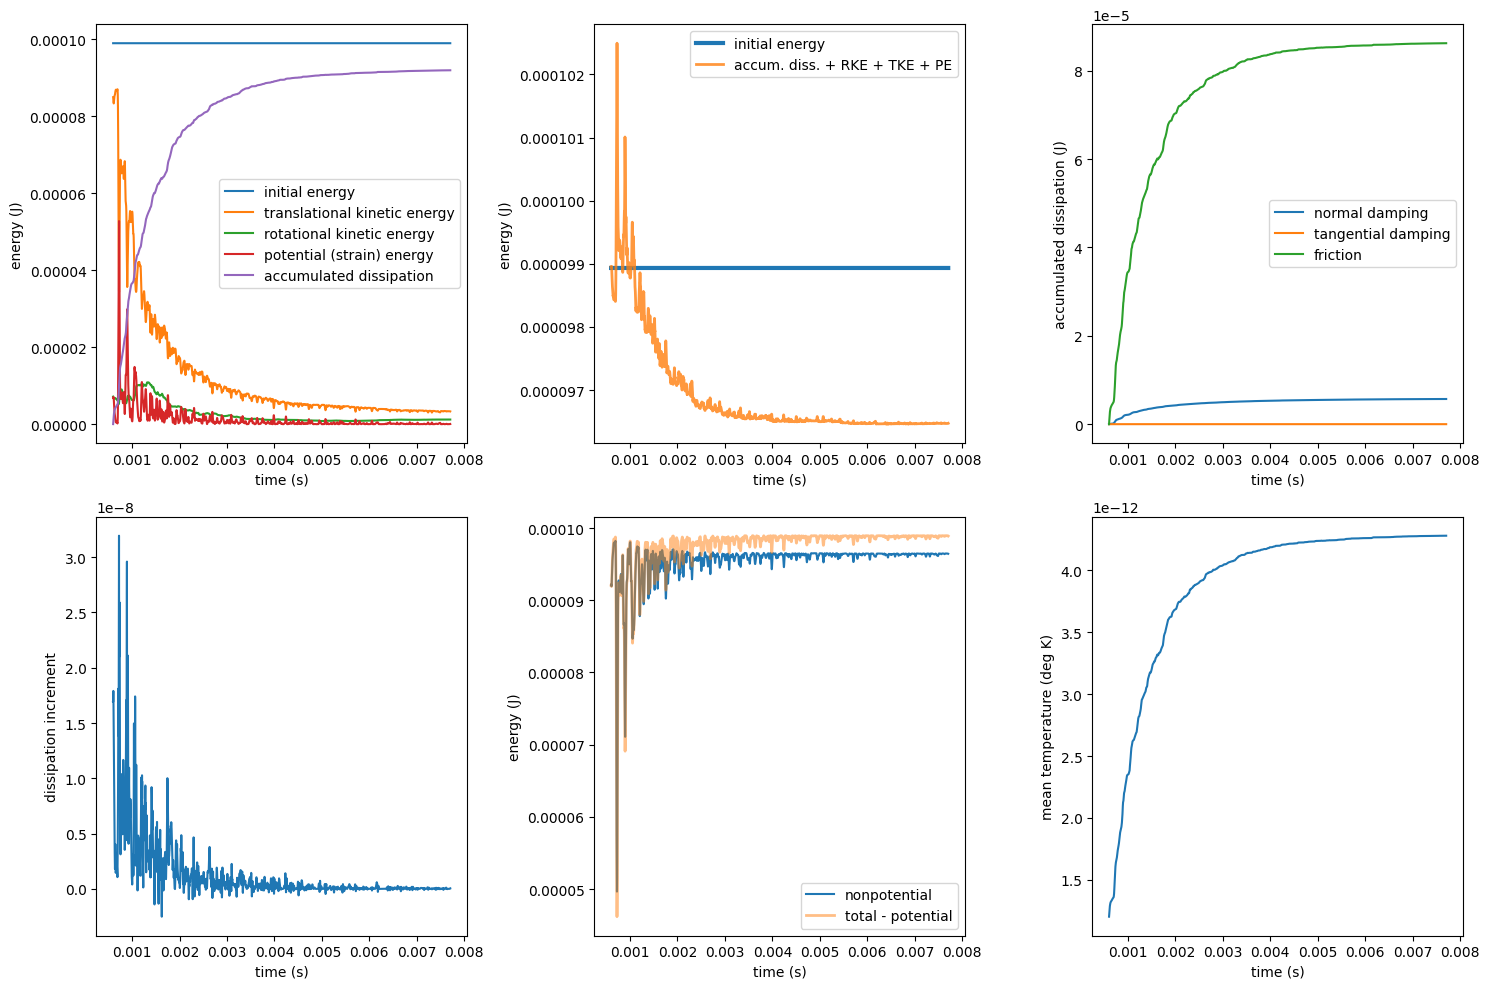

In [304]:

data = np.loadtxt('energy.dat', skiprows=1)
parameters = load_variables_to_dict('info')

time = data[:, 0].astype(int)*parameters['timeStep']
kin_eng = data[:, 1]
rotkin_eng = data[:, 2]
pot_eng = data[:, 3]
diss1 = data[:, 4]*parameters['avewindow']
diss2 = data[:, 5]*parameters['avewindow']
diss3 = data[:, 6]*parameters['avewindow']
meanTemp = data[:, 7]*parameters['avewindow']/64
total_diss = diss1+diss2+diss3
E0 = np.array([kin_eng[0] + pot_eng[0] + rotkin_eng[0]] * len(time))

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs[0,0].set_xlabel('time (s)')
axs[0,0].set_ylabel('energy (J)')
axs[0,0].plot(time, E0, label='initial energy')
axs[0,0].plot(time, kin_eng, label='translational kinetic energy')
axs[0,0].plot(time, rotkin_eng, label='rotational kinetic energy')
axs[0,0].plot(time, pot_eng, label='potential (strain) energy')
axs[0,0].plot(time, np.cumsum(total_diss), label='accumulated dissipation')
axs[0,0].legend()
axs[0,1].set_xlabel('time (s)')
axs[0,1].set_ylabel('energy (J)')
axs[0,1].plot(time, E0, lw=3, label='initial energy')
axs[0,1].plot(time, np.cumsum(total_diss) + kin_eng + rotkin_eng + pot_eng, 
    alpha=0.8, lw=2, label='accum. diss. + RKE + TKE + PE')
axs[0,1].legend()
#axs[0,1].set_ylim(E0[0]*0.9,E0[0]*1.1)
axs[0,2].set_xlabel('time (s)')
axs[0,2].set_ylabel('accumulated dissipation (J)')
axs[0,2].plot(time, np.cumsum(diss1), label='normal damping')
axs[0,2].plot(time, np.cumsum(diss2), label='tangential damping')
axs[0,2].plot(time, np.cumsum(diss3), label='friction')
#axs[0,2].set_yscale('log')
axs[0,2].legend()

axs[1,0].plot(time, diss3)
print('minimum friction dissipation increment =', np.min(diss3))
axs[1,0].set_xlabel('time (s)'); axs[1,0].set_ylabel('dissipation increment')

axs[1,1].plot(time, np.cumsum(total_diss) + kin_eng + rotkin_eng, label='nonpotential')
axs[1,1].plot(time, E0 - pot_eng, alpha=0.5, lw=2, label='total - potential')
axs[1,1].set_xlabel('time (s)'); axs[1,1].set_ylabel('energy (J)')
axs[1,1].legend()

axs[1,2].plot(time, meanTemp)
axs[1,2].set_xlabel('time (s)'); axs[1,2].set_ylabel('mean temperature (deg K)')

plt.tight_layout()


In [113]:
file = 3600000
data = np.loadtxt(f'dumpfiles/all_{file}', skiprows=9)
ind = 13
print(np.sum(data[:,ind])*parameters['timeStep'])
data_con = np.loadtxt(f'dumpfiles/contacts_{file}', skiprows=9)
print(np.sum(data_con[:,ind-11])/2)

8.648650000000001e-13
8.648655e-13
